In [50]:
#Which DRGs are most frequently observed in inpatient hospitalizations?
query= """
SELECT CLM_DRG_CD, COUNT(*) AS FREQUENCY_OF_DRG_INPATIENT_UTLZ 
FROM INPATIENT_CLAIMS
GROUP BY CLM_DRG_CD
ORDER BY FREQUENCY_OF_DRG_INPATIENT_UTLZ DESC
LIMIT 15;
"""
df = pd.read_sql(query, engine)
print(df)

   CLM_DRG_CD  FREQUENCY_OF_DRG_INPATIENT_UTLZ
0         882                              282
1         177                              281
2         886                              275
3         887                              274
4         880                              264
5         181                              264
6         189                              260
7         883                              259
8         876                              259
9         OTH                              258
10        183                              257
11        939                              253
12        885                              252
13        198                              252
14        175                              252


In [96]:
#Which ICD codes are most frequently observed in inpatient hospitalization?

query= """
SELECT ICD9_DGNS_CD_1, 
COUNT(*) AS TOTAL_CLAIMS
FROM INPATIENT_CLAIMS
GROUP BY ICD9_DGNS_CD_1
ORDER BY TOTAL_CLAIMS DESC;
"""
df= pd.read_sql(query, engine)
print(df)

     ICD9_DGNS_CD_1  TOTAL_CLAIMS
0               486          2453
1             V5789          1807
2             41401          1675
3               389          1648
4             49121          1558
...             ...           ...
2731          28851             1
2732           1452             1
2733          33721             1
2734          73340             1
2735          72632             1

[2736 rows x 2 columns]


In [51]:
#Which DRGs are BOTH high-cost AND high-frequency inpatient services?
query = """
SELECT CLM_DRG_CD,
       COUNT(*) AS total_claims,
       SUM(CLM_PMT_AMT) AS total_payment
FROM inpatient_claims
GROUP BY CLM_DRG_CD
ORDER BY total_payment DESC, total_claims DESC LIMIT 20;
"""

df = pd.read_sql(query, engine)
print(df)

   CLM_DRG_CD  total_claims  total_payment
0         939           253      3516800.0
1         948           235      3411700.0
2         949           235      3328000.0
3         945           244      3318000.0
4         951           240      3275000.0
5         946           219      3071100.0
6         941           219      2982600.0
7         950           206      2859850.0
8         864           193      2852000.0
9         862           192      2845530.0
10        940           211      2793800.0
11        854           206      2744300.0
12        947           205      2740700.0
13        872           190      2693700.0
14        853           198      2653900.0
15        871           180      2622300.0
16        858           182      2510000.0
17        865           179      2484000.0
18        866           189      2474090.0
19        181           264      2411000.0


In [103]:
#Which ICD9_DGNS_CD are associated with the highest patient out-of-pocket costs?
query= """
SELECT ICD9_DGNS_CD_1, SUM(NCH_BENE_IP_DDCTBL_AMT + NCH_BENE_PTA_COINSRNC_LBLTY_AM) AS TOTAL_PT_RESPONSIBILITY 
FROM INPATIENT_CLAIMS
WHERE ICD9_DGNS_CD_1 IS NOT NULL
GROUP BY ICD9_DGNS_CD_1
ORDER BY TOTAL_PT_RESPONSIBILITY DESC;
"""

df= pd.read_sql(query, engine)
print(df)

     ICD9_DGNS_CD_1  TOTAL_PT_RESPONSIBILITY
0               486                2624700.0
1             V5789                2131644.0
2               389                2063824.0
3             41401                1758300.0
4             49121                1662900.0
...             ...                      ...
2730           4374                      NaN
2731          81001                      NaN
2732           3081                      NaN
2733          25001                      NaN
2734          81103                      NaN

[2735 rows x 2 columns]


In [31]:
#Which DRG categories are associated with the highest average Medicare spending per inpatient admission?
query = """
SELECT CLM_DRG_CD,
       COUNT(*) AS total_claims,
       AVG(CLM_PMT_AMT) AS avg_payment,
       SUM(CLM_PMT_AMT) AS total_payment
FROM inpatient_claims
GROUP BY CLM_DRG_CD
ORDER BY avg_payment DESC LIMIT 20;
"""

df = pd.read_sql(query, engine)
print(df)

   CLM_DRG_CD  total_claims  avg_payment  total_payment
0           9            23   54217.3913      1247000.0
1           2            24   54041.6667      1297000.0
2           7            13   53615.3846       697000.0
3          13            20   52450.0000      1049000.0
4           3            21   52095.2381      1094000.0
5           8            29   51482.7586      1493000.0
6           1            32   51468.7500      1647000.0
7           6            26   50230.7692      1306000.0
8           4            15   49866.6667       748000.0
9          12            29   48793.1034      1415000.0
10         10            30   48400.0000      1452000.0
11          5            22   46045.4545      1013000.0
12         11            21   45571.4286       957000.0
13        929             5   42600.0000       213000.0
14        928             4   34250.0000       137000.0
15        935             6   33666.6667       202000.0
16        927             2   29500.0000        

In [59]:
#Which DRGs are associated with Higher Length of hospital stay?

query= """
SELECT CLM_DRG_CD, AVG(CLM_UTLZTN_DAY_CNT) AS AVG_LENGTH_OF_STAY_DAYS,
COUNT(*) AS TOTAL_CLAIMS
FROM INPATIENT_CLAIMS
GROUP BY CLM_DRG_CD
ORDER BY AVG_LENGTH_OF_STAY_DAYS DESC;
"""

df= pd.read_sql(query, engine)
print(df)

    CLM_DRG_CD  AVG_LENGTH_OF_STAY_DAYS  TOTAL_CLAIMS
0           13                33.750000            20
1            9                32.173913            23
2            8                29.413793            29
3            2                27.958333            24
4           12                27.620690            29
..         ...                      ...           ...
734        768                 1.875000             8
735        781                 1.833333             6
736        774                 1.800000             5
737        708                 1.764706            17
738        114                 1.750000             4

[739 rows x 3 columns]


  stay_length_group  total_claims  avg_payment
0          15+ days          6624   15595.4544
1         8-14 days          9739   13266.4339
2          4-7 days         21842    9319.1777
3          2-3 days         20438    7177.3579
4             1 day          8130    6951.2632


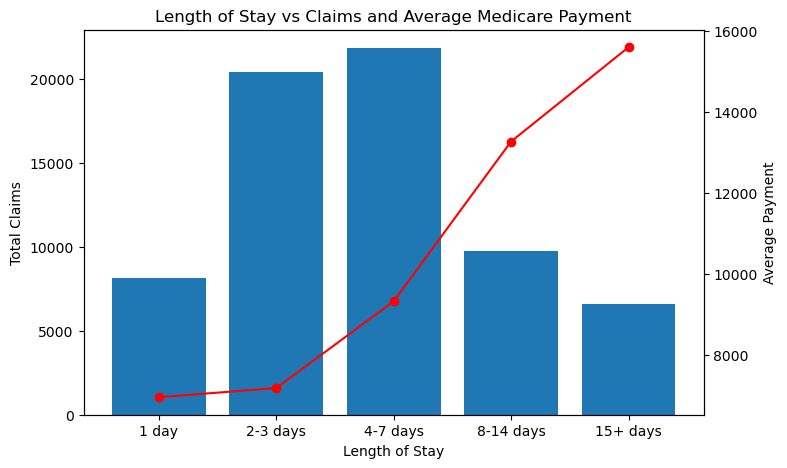

In [68]:
#How does inpatient length of stay influence average Medicare payment per claim?
query = """
SELECT 
    CASE 
        WHEN CLM_UTLZTN_DAY_CNT = 1 THEN '1 day'
        WHEN CLM_UTLZTN_DAY_CNT BETWEEN 2 AND 3 THEN '2-3 days'
        WHEN CLM_UTLZTN_DAY_CNT BETWEEN 4 AND 7 THEN '4-7 days'
        WHEN CLM_UTLZTN_DAY_CNT BETWEEN 8 AND 14 THEN '8-14 days'
        ELSE '15+ days'
    END AS stay_length_group,

    COUNT(*) AS total_claims,
    AVG(COALESCE(CLM_PMT_AMT,0)) AS avg_payment

FROM inpatient_claims
GROUP BY stay_length_group
ORDER BY avg_payment DESC;
"""
df= pd.read_sql(query, engine)
print(df)

import matplotlib.pyplot as plt
import pandas as pd

order = ['1 day', '2-3 days', '4-7 days', '8-14 days', '15+ days']
df['stay_length_group'] = pd.Categorical(df['stay_length_group'], categories=order, ordered=True)
df = df.sort_values('stay_length_group')
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(df['stay_length_group'], df['total_claims'])
ax1.set_xlabel('Length of Stay')
ax1.set_ylabel('Total Claims')

ax2 = ax1.twinx()
ax2.plot(df['stay_length_group'], df['avg_payment'], marker='o', color = "red")
ax2.set_ylabel('Average Payment')

plt.title('Length of Stay vs Claims and Average Medicare Payment')
plt.show()

  STAY_LENGTH_GROUP  AVG_COINSRNC_AMT
0          15+ days          246.3919
1         8-14 days          174.0322
2          4-7 days           70.3736
3          2-3 days           42.2546
4             1 day           34.9077


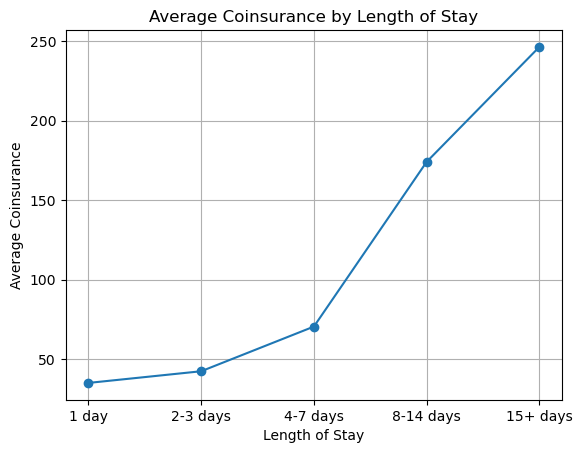

In [64]:
#How does inpatient length of stay influence average coninsurance payment?
query = """
SELECT CASE 
        WHEN CLM_UTLZTN_DAY_CNT = 1 THEN '1 day'
        WHEN CLM_UTLZTN_DAY_CNT BETWEEN 2 AND 3 THEN '2-3 days'
        WHEN CLM_UTLZTN_DAY_CNT BETWEEN 4 AND 7 THEN '4-7 days'
        WHEN CLM_UTLZTN_DAY_CNT BETWEEN 8 AND 14 THEN '8-14 days'
        ELSE '15+ days'
    END AS STAY_LENGTH_GROUP,
AVG(NCH_BENE_PTA_COINSRNC_LBLTY_AM) AS AVG_COINSRNC_AMT 
FROM INPATIENT_CLAIMS
GROUP BY STAY_LENGTH_GROUP
ORDER BY AVG_COINSRNC_AMT DESC;
"""
df= pd.read_sql(query, engine)
print(df)

import matplotlib.pyplot as plt
order = ['1 day', '2-3 days', '4-7 days', '8-14 days', '15+ days']
df['STAY_LENGTH_GROUP'] = pd.Categorical(df['STAY_LENGTH_GROUP'], categories=order, ordered=True)
df = df.sort_values('STAY_LENGTH_GROUP')

plt.plot(df['STAY_LENGTH_GROUP'], df['AVG_COINSRNC_AMT'], marker='o')

plt.title('Average Coinsurance by Length of Stay')
plt.xlabel('Length of Stay')
plt.ylabel('Average Coinsurance')

plt.grid(True)
plt.show()

In [26]:
#Which outpatient services are used the most/frequent?
query = """
SELECT HCPCS_CD_1, COUNT(*) AS total_claims
FROM outpatient_claims
GROUP BY HCPCS_CD_1
ORDER BY total_claims DESC;
"""
df=pd.read_sql(query, engine)
print(df)

     HCPCS_CD_1  total_claims
0         36415        161373
1          None        144530
2         99213         31792
3         99212         23658
4         80053         22883
...         ...           ...
2528      85597             1
2529      80173             1
2530      47000             1
2531      46945             1
2532      90717             1

[2533 rows x 2 columns]


In [85]:
#Which outpatient services drive the highest total Medicare spending?
query = """
SELECT HCPCS_CD_1,
       COUNT(*) AS total_claims,
       SUM(CLM_PMT_AMT) AS total_payment
FROM outpatient_claims
WHERE HCPCS_CD_1 IS  NOT NULL
GROUP BY HCPCS_CD_1
ORDER BY total_payment DESC LIMIT 20;
"""
df= pd.read_sql(query, engine)
print(df)

   HCPCS_CD_1  total_claims  total_payment
0       A4657         20237     38757960.0
1       36415        161373     26543690.0
2       97110         18410      6164830.0
3       99213         31792      5918100.0
4       99212         23658      4448470.0
5       80053         22883      4358430.0
6       99214         14890      2878340.0
7       99211         11512      2715300.0
8       80048         13866      2612220.0
9       71020         12244      2502580.0
10      97001          5484      1717160.0
11      G0283          5701      1674630.0
12      A0425          4865      1532240.0
13      85610         19812      1514890.0
14      88305          5085      1400220.0
15      90999           673      1265190.0
16      Q4081           603      1131300.0
17      G0202         13462      1012530.0
18      85025          3628       864900.0
19      82040           852       813510.0


In [83]:
#Which HCPCS CODE have highest patient coinsurance payment?
query= """
SELECT HCPCS_CD_1, SUM(NCH_BENE_PTB_COINSRNC_AMT) AS TOTAL_COINSURANCE_AMT 
FROM OUTPATIENT_CLAIMS
WHERE HCPCS_CD_1 IS NOT NULL
GROUP BY HCPCS_CD_1
ORDER BY TOTAL_COINSURANCE_AMT DESC;
"""

df= pd.read_sql(query, engine)
print(df)

     HCPCS_CD_1  TOTAL_COINSURANCE_AMT
0         A4657             10091230.0
1         36415              7117870.0
2         99213              1770800.0
3         97110              1763700.0
4         99212              1288510.0
...         ...                    ...
2527      91299                    0.0
2528      J9218                    0.0
2529      S0077                    0.0
2530      46050                    0.0
2531      47000                    0.0

[2532 rows x 2 columns]


In [79]:
#Which diagnoses are most common in outpatient care?
query = """
SELECT ICD9_DGNS_CD_1,
       COUNT(*) AS total_claims
FROM outpatient_claims
WHERE ICD9_DGNS_CD_1 IS NOT NULL
AND ICD9_DGNS_CD_1 <> 'OTHER'
GROUP BY ICD9_DGNS_CD_1
ORDER BY total_claims DESC;
"""
df= pd.read_sql(query, engine)
print(df)

      ICD9_DGNS_CD_1  total_claims
0               4019         19079
1               4011         18816
2               2721          4677
3               2723          4627
4               2722          4602
...              ...           ...
10977          63431             1
10978          94400             1
10979          64821             1
10980          85314             1
10981          85221             1

[10982 rows x 2 columns]


In [101]:
#Further analysis- since 4019 and 4011 icd codes (Hypertension can cause Stroke and TIA) are frquent in outpatient.
#What percent of the total cost associates with Stroke and TIA services?

query = """
WITH total_cost AS (
    SELECT 
        SUM(
            COALESCE(MEDREIMB_IP,0) + COALESCE(BENRES_IP,0) + COALESCE(PPPYMT_IP,0) +
            COALESCE(MEDREIMB_OP,0) + COALESCE(BENRES_OP,0) + COALESCE(PPPYMT_OP,0) +
            COALESCE(MEDREIMB_CAR,0) + COALESCE(BENRES_CAR,0) + COALESCE(PPPYMT_CAR,0)
        ) AS overall_cost
    FROM beneficiary_summary
),

stroke_cost AS (
    SELECT 
        SUM(
            COALESCE(MEDREIMB_IP,0) + COALESCE(BENRES_IP,0) + COALESCE(PPPYMT_IP,0) +
            COALESCE(MEDREIMB_OP,0) + COALESCE(BENRES_OP,0) + COALESCE(PPPYMT_OP,0) +
            COALESCE(MEDREIMB_CAR,0) + COALESCE(BENRES_CAR,0) + COALESCE(PPPYMT_CAR,0)
        ) AS stroke_total_cost
    FROM beneficiary_summary
    WHERE SP_STRKETIA = 1
)

SELECT 
    stroke_total_cost,
    overall_cost,
    (stroke_total_cost / overall_cost) * 100 AS percent_cost_due_to_stroke
FROM stroke_cost, total_cost;
"""

df = pd.read_sql(query, engine)
print(df)

   stroke_total_cost  overall_cost  percent_cost_due_to_stroke
0        110250184.0   572106116.0                     19.2709


In [78]:
#Which diagnoses are most expensive in outpatient care?
query = """
SELECT 
    ICD9_DGNS_CD_1,
    COUNT(*) AS total_claims,
    AVG(COALESCE(CLM_PMT_AMT, 0)) AS avg_payment,
    SUM(COALESCE(CLM_PMT_AMT, 0)) AS total_payment
FROM outpatient_claims
WHERE ICD9_DGNS_CD_1 IS NOT NULL
  AND ICD9_DGNS_CD_1 <> 'OTHER'
  AND COALESCE(CLM_PMT_AMT, 0) >= 0
GROUP BY ICD9_DGNS_CD_1
HAVING COUNT(*) >= 50
ORDER BY total_payment DESC;
"""

df= pd.read_sql(query, engine)
print(df)

     ICD9_DGNS_CD_1  total_claims  avg_payment  total_payment
0              V562          1479    1497.8161      2215270.0
1              V560          1474    1454.7626      2144320.0
2              7925          1464    1452.1721      2125980.0
3             V5631          1448    1465.9047      2122630.0
4              5855          1452    1458.3609      2117540.0
...             ...           ...          ...            ...
3218          V7183            65      38.6154         2510.0
3219           V029            63      38.4127         2420.0
3220           V045            61      39.0164         2380.0
3221           V038            67      35.2239         2360.0
3222           V039            54      40.3704         2180.0

[3223 rows x 4 columns]


In [100]:
#Further analysis as V560 , V562 (extracorporeal dialysis, dialysis and dialysis catheter care) are associated with Chronic Kidney disease.
#What percent of the total_cost accounts for Chronic Kidney Disease services?

query = """
WITH total_cost AS (
    SELECT 
        SUM(
            COALESCE(MEDREIMB_IP,0) + COALESCE(BENRES_IP,0) + COALESCE(PPPYMT_IP,0) +
            COALESCE(MEDREIMB_OP,0) + COALESCE(BENRES_OP,0) + COALESCE(PPPYMT_OP,0) +
            COALESCE(MEDREIMB_CAR,0) + COALESCE(BENRES_CAR,0) + COALESCE(PPPYMT_CAR,0)
        ) AS overall_cost
    FROM beneficiary_summary
),

CKD_cost AS (
    SELECT 
        SUM(
            COALESCE(MEDREIMB_IP,0) + COALESCE(BENRES_IP,0) + COALESCE(PPPYMT_IP,0) +
            COALESCE(MEDREIMB_OP,0) + COALESCE(BENRES_OP,0) + COALESCE(PPPYMT_OP,0) +
            COALESCE(MEDREIMB_CAR,0) + COALESCE(BENRES_CAR,0) + COALESCE(PPPYMT_CAR,0)
        ) AS CKD_total_cost
    FROM beneficiary_summary
    WHERE SP_CHRNKIDN = 1
)

SELECT 
    CKD_total_cost,
    overall_cost,
    (CKD_total_cost / overall_cost) * 100 AS percent_cost_due_to_CKD
FROM CKD_cost, total_cost;
"""

df = pd.read_sql(query, engine)
print(df)

   CKD_total_cost  overall_cost  percent_cost_due_to_CKD
0     331128760.0   572106116.0                  57.8789


   avg_claim_payment  avg_primary_payer_paid  avg_deductible  avg_coinsurance
0           283.9246                 10.2398          2.8255          83.8459


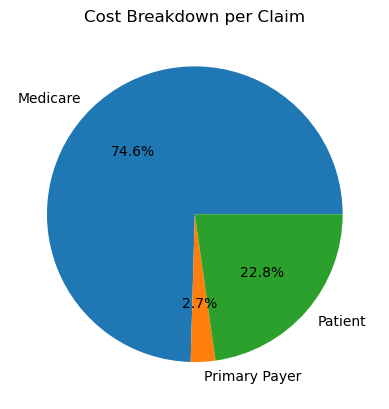

In [88]:
#How much financial burden on average falls on the patient in outpatient care?
query = """
SELECT AVG(CLM_PMT_AMT) AS avg_claim_payment,
       AVG(NCH_PRMRY_PYR_CLM_PD_AMT) AS avg_primary_payer_paid,
       AVG(NCH_BENE_PTB_DDCTBL_AMT) AS avg_deductible,
       AVG(NCH_BENE_PTB_COINSRNC_AMT) AS avg_coinsurance
FROM outpatient_claims;
"""

df= pd.read_sql(query, engine)
print(df)

import matplotlib.pyplot as plt

medicare = df['avg_claim_payment'][0]
primary = df['avg_primary_payer_paid'][0]
patient = df['avg_deductible'][0] + df['avg_coinsurance'][0]

labels = ['Medicare', 'Primary Payer', 'Patient']
values = [medicare, primary, patient]
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title('Cost Breakdown per Claim')
plt.show()

In [35]:
#How do inpatient Medicare spending and patient out-of-pocket burden differ between beneficiaries with and without Heart Failure?
query = """
SELECT SP_CHF,
       COUNT(*) AS beneficiaries,
       AVG(MEDREIMB_IP) AS avg_ip_reimb,
       AVG(BENRES_IP) AS avg_beneficiary_ip_responsibility
FROM beneficiary_summary
GROUP BY SP_CHF;
"""

df=pd.read_sql(query, engine)
print(df)

   SP_CHF  beneficiaries  avg_ip_reimb  avg_beneficiary_ip_responsibility
0       2          83197      542.5125                            65.3533
1       1          33155     6408.9564                           710.0186


In [34]:
#How do inpatient Medicare spending and patient out-of-pocket burden differ between beneficiaries with and without diabetes?
query = """
SELECT SP_DIABETES,
       COUNT(*) AS beneficiaries,
       AVG(MEDREIMB_IP) AS avg_ip_reimb,
       AVG(BENRES_IP) AS avg_beneficiary_ip_responsibility
FROM beneficiary_summary
GROUP BY SP_DIABETES;
"""

df=pd.read_sql(query, engine)
print(df)

   SP_DIABETES  beneficiaries  avg_ip_reimb  avg_beneficiary_ip_responsibility
0            2          72292      586.1329                            67.4371
1            1          44060     4885.4208                           547.0428


In [37]:
#How do inpatient Medicare spending and patient out-of-pocket burden differ between beneficiaries with and without Ischemic Heart Disease?
query = """
SELECT SP_ISCHMCHT,
       COUNT(*) AS beneficiaries,
       AVG(MEDREIMB_IP) AS avg_ip_reimb,
       AVG(BENRES_IP) AS avg_beneficiary_ip_responsibility
FROM beneficiary_summary
GROUP BY SP_ISCHMCHT;
"""

df=pd.read_sql(query, engine)
print(df)

   SP_ISCHMCHT  beneficiaries  avg_ip_reimb  avg_beneficiary_ip_responsibility
0            2          67410      318.5520                            41.7343
1            1          48942     4825.1148                           534.6033


   SP_DIABETES  total_beneficiaries  avg_inpatient_spending  \
0            2                72292                586.1329   
1            1                44060               4885.4208   

   avg_outpatient_spending  avg_op_to_ip_ratio  
0                 253.8273            0.148334  
1                1226.6823            0.295717  


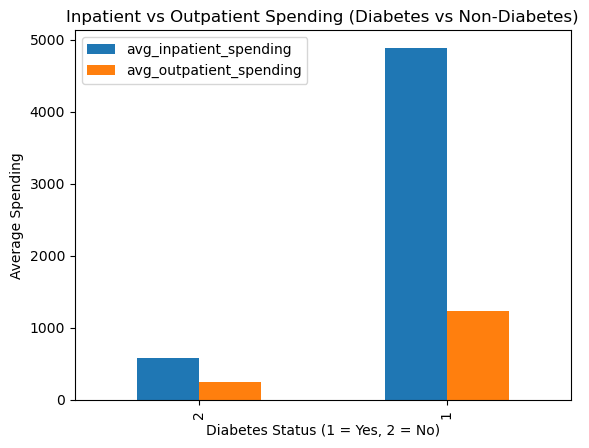

In [45]:
#Do Diabetes patients rely more on outpatient services than inpatient care?
query= """
SELECT 
    SP_DIABETES,
    COUNT(*) AS total_beneficiaries,
    
    AVG(COALESCE(MEDREIMB_IP,0)) AS avg_inpatient_spending,
    AVG(COALESCE(MEDREIMB_OP,0)) AS avg_outpatient_spending,
    
    AVG(
        CASE 
            WHEN COALESCE(MEDREIMB_IP,0) = 0 THEN NULL
            ELSE MEDREIMB_OP / MEDREIMB_IP
        END
    ) AS avg_op_to_ip_ratio

FROM beneficiary_summary
GROUP BY SP_DIABETES;
"""
df=pd.read_sql(query, engine)
print(df)

import matplotlib.pyplot as plt

df.plot(
    x='SP_DIABETES',
    y=['avg_inpatient_spending', 'avg_outpatient_spending'],
    kind='bar'
)

plt.title('Inpatient vs Outpatient Spending (Diabetes vs Non-Diabetes)')
plt.xlabel('Diabetes Status (1 = Yes, 2 = No)')
plt.ylabel('Average Spending')
plt.show()

   SP_CNCR  total_beneficiaries  avg_inpatient_spending  \
0        2               108937               1800.6943   
1        1                 7415               8288.8901   

   avg_outpatient_spending  avg_op_to_ip_ratio  
0                 552.3772            0.268775  
1                1648.4127            0.246490  


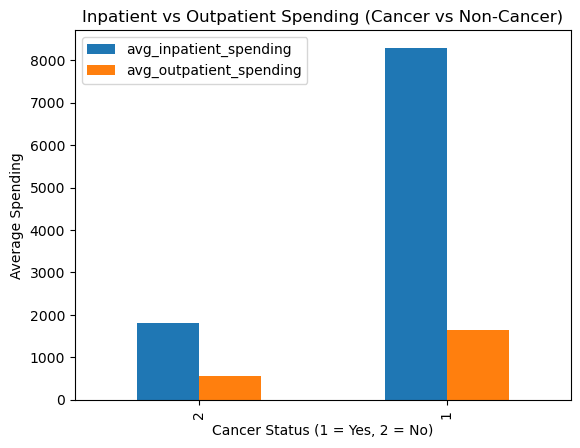

In [43]:
#Do cancer patients rely more on outpatient services than inpatient care?
query= """
SELECT 
    SP_CNCR,
    COUNT(*) AS total_beneficiaries,
    
    AVG(COALESCE(MEDREIMB_IP,0)) AS avg_inpatient_spending,
    AVG(COALESCE(MEDREIMB_OP,0)) AS avg_outpatient_spending,
    
    AVG(
        CASE 
            WHEN COALESCE(MEDREIMB_IP,0) = 0 THEN NULL
            ELSE MEDREIMB_OP / MEDREIMB_IP
        END
    ) AS avg_op_to_ip_ratio

FROM beneficiary_summary
GROUP BY SP_CNCR;
"""
df=pd.read_sql(query, engine)
print(df)

import matplotlib.pyplot as plt

df.plot(
    x='SP_CNCR',
    y=['avg_inpatient_spending', 'avg_outpatient_spending'],
    kind='bar'
)

plt.title('Inpatient vs Outpatient Spending (Cancer vs Non-Cancer)')
plt.xlabel('Cancer Status (1 = Yes, 2 = No)')
plt.ylabel('Average Spending')
plt.show()

In [42]:
#Which outpatient procedures are most common among cancer patients?
query= """
SELECT O.HCPCS_CD_1, COUNT(*) AS TOTAL_CLAIMS
FROM OUTPATIENT_CLAIMS O JOIN BENEFICIARY_SUMMARY B ON O.DESYNPUF_ID = B.DESYNPUF_ID
WHERE B.SP_CNCR = 1
GROUP BY O.HCPCS_CD_1;
"""
df=pd.read_sql(query, engine)
print(df)

     HCPCS_CD_1  TOTAL_CLAIMS
0         88305           615
1         78465           139
2         99212          2785
3         80048          1627
4         36591            42
...         ...           ...
1494      A6223             1
1495      88311             1
1496      A9576             1
1497      94250             1
1498      72149             1

[1499 rows x 2 columns]


In [32]:
#How does average Medicare spending differ by gender across inpatient, outpatient, and physician services?
query = """
SELECT BENE_SEX_IDENT_CD,
       AVG(MEDREIMB_IP) AS avg_ip_reimb,
       AVG(MEDREIMB_OP) AS avg_op_reimb,
       AVG(MEDREIMB_CAR) AS avg_car_reimb
FROM beneficiary_summary
GROUP BY BENE_SEX_IDENT_CD;
"""

df= pd.read_sql(query, engine)
print(df)

   BENE_SEX_IDENT_CD  avg_ip_reimb  avg_op_reimb  avg_car_reimb
0                  1     2198.1704      580.7130      1116.8280
1                  2     2227.1203      655.7776      1198.6812


In [76]:
#What is state level medicare spending variation?
query = """
SELECT 
    SP_STATE_CODE,
    AVG(MEDREIMB_IP + MEDREIMB_OP + MEDREIMB_CAR) AS avg_total_spending
FROM beneficiary_summary
GROUP BY SP_STATE_CODE
ORDER BY avg_total_spending DESC LIMIT 25;
"""
df= pd.read_sql(query, engine)
print(df)

    SP_STATE_CODE  avg_total_spending
0              18           4947.7843
1              45           4822.2706
2              25           4795.0338
3              31           4768.1392
4              36           4746.0407
5              21           4677.2020
6              11           4658.4562
7              19           4633.9359
8              15           4629.0989
9              14           4627.9472
10             42           4527.5758
11             17           4503.3275
12             26           4465.2860
13             33           4426.1214
14             10           4391.1207
15             23           4294.6710
16             16           4250.9947
17             49           4137.9067
18             22           4123.0847
19             28           4098.9481
20             39           4037.7842
21              7           3968.9749
22             37           3934.4859
23             34           3890.0584
24             29           3853.3967


   BENE_RACE_CD  avg_chronic_burden  avg_total_payment
0             1              1.5241          4076.2979
1             2              1.3859          3937.1150
2             5              1.2931          3437.2298
3             3              1.1657          2942.7297


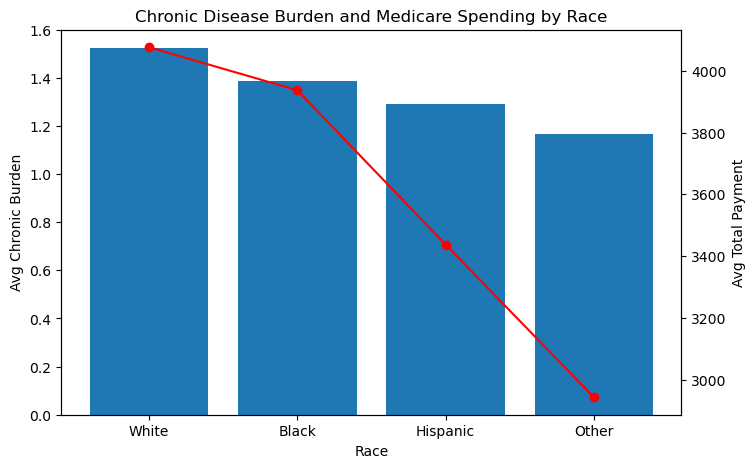

In [77]:
#Which racial groups have higher chronic disease burden and how does their Medicare spending compare?
query = """ 
SELECT 
    BENE_RACE_CD,

    AVG(
        (SP_CHF=1) + (SP_CHRNKIDN=1) + (SP_CNCR=1) + 
        (SP_COPD=1) + (SP_DIABETES=1) + 
        (SP_ISCHMCHT=1) + (SP_STRKETIA=1)
    ) AS avg_chronic_burden,

    AVG(
        COALESCE(MEDREIMB_IP,0) + 
        COALESCE(MEDREIMB_OP,0) + 
        COALESCE(MEDREIMB_CAR,0)
    ) AS avg_total_payment

FROM beneficiary_summary
GROUP BY BENE_RACE_CD
ORDER BY avg_chronic_burden DESC;
"""
df= pd.read_sql(query, engine)
print(df)

import matplotlib.pyplot as plt

race_map = {
    1: 'White',
    2: 'Black',
    3: 'Other',
    5: 'Hispanic'
}
df['Race'] = df['BENE_RACE_CD'].map(race_map)

df = df.sort_values('avg_chronic_burden', ascending=False)
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(df['Race'], df['avg_chronic_burden'])
ax1.set_xlabel('Race')
ax1.set_ylabel('Avg Chronic Burden')

ax2 = ax1.twinx()
ax2.plot(df['Race'], df['avg_total_payment'], marker='o', color='red')
ax2.set_ylabel('Avg Total Payment')

plt.title('Chronic Disease Burden and Medicare Spending by Race')
plt.show()

In [71]:
#Which beneficiaries have the highest total annual Medicare spending and patient financial burden, and how many chronic conditions do they have?
query = """
WITH patient_cost AS (
    SELECT
        DESYNPUF_ID,
        BENE_SEX_IDENT_CD,
        BENE_RACE_CD,
        SP_STATE_CODE,
        COALESCE(MEDREIMB_IP,0) + COALESCE(MEDREIMB_OP,0) + COALESCE(MEDREIMB_CAR,0) AS total_medicare_reimb,
        COALESCE(BENRES_IP,0) + COALESCE(BENRES_OP,0) + COALESCE(BENRES_CAR,0) AS total_patient_responsibility,
        (
            CASE WHEN SP_CHF = 1 THEN 1 ELSE 0 END +
            CASE WHEN SP_CHRNKIDN = 1 THEN 1 ELSE 0 END +
            CASE WHEN SP_CNCR = 1 THEN 1 ELSE 0 END +
            CASE WHEN SP_COPD = 1 THEN 1 ELSE 0 END +
            CASE WHEN SP_DIABETES = 1 THEN 1 ELSE 0 END +
            CASE WHEN SP_ISCHMCHT = 1 THEN 1 ELSE 0 END +
            CASE WHEN SP_STRKETIA = 1 THEN 1 ELSE 0 END
        ) AS chronic_condition_count
    FROM beneficiary_summary
),
ranked_patients AS (
    SELECT
        *,
        RANK() OVER (ORDER BY total_medicare_reimb DESC) AS medicare_cost_rank,
        RANK() OVER (ORDER BY total_patient_responsibility DESC) AS patient_burden_rank
    FROM patient_cost
)
SELECT
    DESYNPUF_ID,
    BENE_SEX_IDENT_CD,
    BENE_RACE_CD,
    SP_STATE_CODE,
    total_medicare_reimb,
    total_patient_responsibility,
    chronic_condition_count,
    medicare_cost_rank,
    patient_burden_rank
FROM ranked_patients
ORDER BY medicare_cost_rank
LIMIT 20;
"""

df= pd.read_sql(query, engine)
print(df)

         DESYNPUF_ID  BENE_SEX_IDENT_CD  BENE_RACE_CD  SP_STATE_CODE  \
0   3A9D94388C426924                  1             2              1   
1   F8F72B475A3381DC                  1             3             45   
2   8F43AE15B6CD7F39                  2             1             36   
3   B010E908FD8DED6A                  1             1             33   
4   1DE6BA3E9EBE52A7                  2             3             33   
5   7248DAB016E8C3A5                  1             1             52   
6   ED29D09DDA6FA023                  2             1             26   
7   893882C572AC525E                  2             1             30   
8   2BA942B99BDFB446                  1             1             32   
9   817FCE82A9FDD269                  1             3             52   
10  E9AD8ED84454D577                  1             2             14   
11  E2D39E24FCF427D5                  2             2              9   
12  3E9728662118C096                  1             1           

In [38]:
#Which providers have the highest outpatient Medicare payments, and how do they rank by volume and payment?
query = """
WITH provider_summary AS (
    SELECT
        PRVDR_NUM,
        COUNT(*) AS outpatient_claim_count,
        SUM(COALESCE(CLM_PMT_AMT,0)) AS total_medicare_payment,
        AVG(COALESCE(CLM_PMT_AMT,0)) AS avg_medicare_payment
    FROM outpatient_claims
    WHERE PRVDR_NUM IS NOT NULL
    GROUP BY PRVDR_NUM
)
SELECT
    PRVDR_NUM,
    outpatient_claim_count,
    total_medicare_payment,
    avg_medicare_payment,
    RANK() OVER (ORDER BY total_medicare_payment DESC) AS payment_rank,
    RANK() OVER (ORDER BY outpatient_claim_count DESC) AS volume_rank
FROM provider_summary
ORDER BY payment_rank
LIMIT 20;
"""

df= pd.read_sql(query, engine)
print(df)

   PRVDR_NUM  outpatient_claim_count  total_medicare_payment  \
0     0502NA                    9906               2892110.0   
1     2201DT                    6084               1774980.0   
2     0505TK                    5755               1741690.0   
3     2301GU                    4421               1269740.0   
4     3300KJ                    3951               1175830.0   
5     3400ZQ                    3870               1157150.0   
6     4500NJ                    3783               1117830.0   
7     10018S                    3582               1001380.0   
8     1700JJ                    3632                996660.0   
9     3600WB                    3502                922140.0   
10    3302QH                    2942                895720.0   
11    4600BC                    2528                880960.0   
12    3902NU                    3466                874080.0   
13    1000VH                    3394                849460.0   
14    0500RN                    2551    